In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [3]:
from catrace.response import run_response, RunResponseParams, load_all_dff
from catrace.visualize import PlotBoxplotByCondParams

In [4]:
from catrace.dataset import load_dataset_config
from catrace.stats import sort_conditions
config_file = '../juvenile_dataset_without14mm_phearg.json'
dsconfig = load_dataset_config(config_file)
dff = load_all_dff(dsconfig)
dff = sort_conditions(dff.T, dsconfig.conditions).T
convert_to_rate = True

if convert_to_rate:
    dff = dff * dsconfig.frame_rate

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/process_time_trace.py:198: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(level='odor').mean()


{
    "Kruskal": {
        "statistic": 661.9605695985374,
        "p_value": 3.716202812815094e-143,
        "n": {
            "arg-phe": 39039,
            "naive": 27177,
            "phe-arg": 40137,
            "phe-trp": 23280
        }
    },
    "mean": {
        "arg-phe": 0.9505521007750056,
        "naive": 0.899379195134982,
        "phe-arg": 1.0706914939007897,
        "phe-trp": 1.0305487855682764
    },
    "std": {
        "arg-phe": 1.0576856351360446,
        "naive": 0.9310802706772214,
        "phe-arg": 1.0975021461471692,
        "phe-trp": 1.1075305311474548
    },
    "Dunn_naive": {
        "p_values": {
            "arg-phe": 2.920937958058048e-10,
            "phe-arg": 6.07028123170208e-104,
            "phe-trp": 2.8497028662270894e-45
        },
        "z_statistics": {
            "arg-phe": 6.5760705079498445,
            "phe-arg": 21.772725673999144,
            "phe-trp": 14.261885968026458
        },
        "n": {
            "arg-phe": [
       

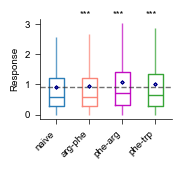

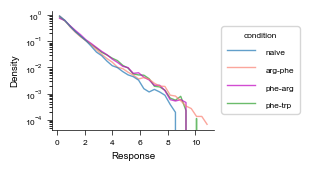

In [8]:
color_dict = {'naive': 'tab:blue', 
              'arg-phe': 'salmon',
              'phe-arg': 'm',
              'phe-trp': 'tab:green',
}
colors = [color_dict[c] for c in dsconfig.conditions]
# colors = ['tab:blue', 'tab:brown', 'tab:green', 'm']
boxplot_params = PlotBoxplotByCondParams(
    figsize=(2.0, 1.8),
    do_plot_strip=False,
    hline_linewidth=1.0,
    mean_marker_size=0.5,
    box_linewidth=1,
    box_colors=colors,
    mean_marker_color='darkblue')
histplot_params = dict(
    binwidth=0.05 * dsconfig.frame_rate,
    log_scale=True,
    figsize=(3.2, 1.8),
    label_fontsize=7,
    tick_label_fontsize=6,
    colors = colors,
    linewidth=1,
    alpha=0.7,
)
params = RunResponseParams(
    dff = dff,
    dsconfig = dsconfig,
    time_window = [38, 63], #[37, 52],
    top_ratio = None,
    odor_key = 'odors_aa',
    boxplot_params = boxplot_params,
    histplot_params = histplot_params,
)

resp, test_results, fig_box, fig_hist = run_response(params)
import json
print(json.dumps(test_results, indent=4))

In [9]:
from catrace.stats import format_test_results_by_cond
print(format_test_results_by_cond(test_results))

(Kruskal–Wallis test, n = 129633, d.f. = 3, H = 661.96, P = 3.7 × 10^-143). Group statistics: arg-phe: mean = 0.9506 ± 1.058 (n = 39039); naive: mean = 0.8994 ± 0.9311 (n = 27177); phe-arg: mean = 1.071 ± 1.098 (n = 40137); and phe-trp: mean = 1.031 ± 1.108 (n = 23280). Nonparametric multiple comparisons against naive (n = 27177): arg-phe, Q = 6.58, P = 2.9 × 10^-10, n = 27177; phe-arg, Q = 21.77, P = 6.1 × 10^-104, n = 40137; and phe-trp, Q = 14.26, P = 2.8 × 10^-45, n = 23280.


In [10]:
from catrace.for_paper import save_figure_for_paper, save_stats_json

paper_fig_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
fig_name = f'{dataset_name}_response_{params.odor_key}_boxplot'
save_figure_for_paper(fig_box, fig_name, paper_fig_dir)
save_stats_json(test_results, fig_name, paper_fig_dir)

fig_name = f'{dataset_name}_response_{params.odor_key}_histplot'
save_figure_for_paper(fig_hist, fig_name, paper_fig_dir)


/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/process_time_trace.py:198: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(level='odor').mean()


{
    "Kruskal": {
        "statistic": 1321.605679763772,
        "p_value": 3.018507519501515e-286,
        "n": {
            "arg-phe": 39039,
            "naive": 27177,
            "phe-arg": 40137,
            "phe-trp": 23280
        }
    },
    "mean": {
        "arg-phe": 0.08635848055136827,
        "naive": 0.10572944074216437,
        "phe-arg": 0.11181566371600543,
        "phe-trp": 0.10322242915473956
    },
    "std": {
        "arg-phe": 0.111954007237264,
        "naive": 0.12884877404028033,
        "phe-arg": 0.1305666227875797,
        "phe-trp": 0.1367716413448666
    },
    "Dunn_naive": {
        "p_values": {
            "arg-phe": 1.8911390904479741e-88,
            "phe-arg": 1.3412646655741072e-08,
            "phe-trp": 0.21022840820986705
        },
        "z_statistics": {
            "arg-phe": -20.06582873060239,
            "phe-arg": 5.980637466938953,
            "phe-trp": -2.1079776328439
        },
        "n": {
            "arg-phe": [
      

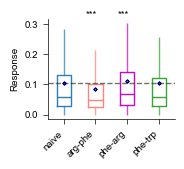

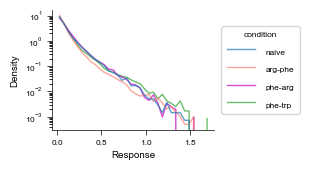

In [8]:
params = RunResponseParams(
    dff=dff,
    dsconfig=dsconfig,
    time_window=[37, 52],
    top_ratio=None,
    odor_key='odors_ba',
    boxplot_params=boxplot_params,
    histplot_params=histplot_params,
)

resp, test_results, fig_box, fig_hist = run_response(params)
# test_results is a dictionary
# Print the test results as a formatted json with 4 spaces indentation
import json
print(json.dumps(test_results, indent=4))

/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/process_time_trace.py:198: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(level='odor').mean()


{
    "Kruskal": {
        "statistic": 1806.0143121783622,
        "p_value": 0.0,
        "n": {
            "arg-phe": 78078,
            "naive": 54354,
            "phe-arg": 80274,
            "phe-trp": 46560
        }
    },
    "mean": {
        "arg-phe": 0.11791938525955482,
        "naive": 0.12411889517963082,
        "phe-arg": 0.1405777488502061,
        "phe-trp": 0.13415478081309695
    },
    "std": {
        "arg-phe": 0.15045718131229174,
        "naive": 0.14362691303166272,
        "phe-arg": 0.16035492807765625,
        "phe-trp": 0.1643456833897212
    },
    "Dunn_naive": {
        "p_values": {
            "arg-phe": 2.137318281393308e-13,
            "phe-arg": 2.9089544459595497e-85,
            "phe-trp": 7.719401629074535e-24
        },
        "z_statistics": {
            "arg-phe": -7.576975214759228,
            "phe-arg": 19.67421544597396,
            "phe-trp": 10.244829709021452
        },
        "n": {
            "arg-phe": [
                780

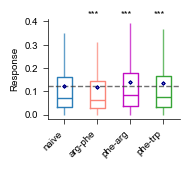

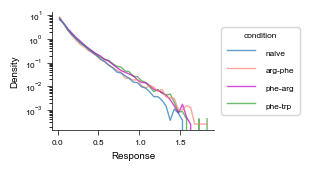

In [9]:
params = RunResponseParams(
    dff=dff,
    dsconfig=dsconfig,
    time_window=[37, 52],
    top_ratio=None,
    odor_key='odors_stimuli',
    boxplot_params = boxplot_params,
    histplot_params=histplot_params,
)

resp, test_results, fig_box, fig_hist = run_response(params)
print(json.dumps(test_results, indent=4))